In [43]:
import os
import numpy as np
import sys
import pickle
import numpy as np
import json
from tqdm import tqdm
import polars as pl
from matplotlib import pyplot as plt
from ecg.utils.misc import get_scale_xy_from_homo_mat
import cv2

In [62]:
from ecg.utils.metrics import match_single_image
import numpy as np
import time
from tqdm import tqdm
import numpy as np
from numba import njit
from joblib import Parallel, delayed


import os
import numpy as np
import matplotlib.pyplot as plt

def viz_img_keypoints(
    img,
    kpt_xys,
    kpt_classes,
    save_path=None,
    point_size=30,
    alpha=0.9,
    show_legend=False,
    dpi=100,
):
    """
    Visualize N keypoints on an RGB image using matplotlib.
    Ensures saved output has EXACT same shape as input image.

    Args:
        img (np.ndarray): RGB image, shape (H, W, 3)
        kpt_xys (array-like): (N, 2) keypoints in (x, y) pixel coordinates
        kpt_classes (array-like): (N,) integer class labels
        save_path (str | None): path to save visualization
        point_size (int): scatter point size
        alpha (float): point transparency
        show_legend (bool): whether to show legend
        dpi (int): fixed DPI to ensure pixel-perfect output

    Returns:
        fig, ax
    """
    img = np.asarray(img)
    kpt_xys = np.asarray(kpt_xys)
    kpt_classes = np.asarray(kpt_classes)

    assert img.ndim == 3 and img.shape[2] == 3, "img must be HxWx3 RGB"
    assert kpt_xys.shape[0] == kpt_classes.shape[0]
    assert kpt_xys.shape[1] == 2

    H, W = img.shape[:2]

    # ------------------------------------------------------------
    # Pixel-perfect figure: size in inches = pixels / dpi
    # ------------------------------------------------------------
    fig = plt.figure(figsize=(W / dpi, H / dpi), dpi=dpi)
    ax = plt.axes([0, 0, 1, 1])  # fill entire canvas
    ax.axis("off")

    ax.imshow(img, interpolation="nearest")

    # Unique classes → consistent colors
    unique_classes = np.unique(kpt_classes)
    cmap = plt.get_cmap("tab10")
    class_to_color = {cls: cmap(i % cmap.N) for i, cls in enumerate(unique_classes)}

    # Plot per class
    for cls in unique_classes:
        mask = kpt_classes == cls
        if not np.any(mask):
            continue

        pts = kpt_xys[mask]
        ax.scatter(
            pts[:, 0],
            pts[:, 1],
            s=point_size,
            c=[class_to_color[cls]],
            alpha=alpha,
            label=f"class {cls}",
        )

    if show_legend:
        ax.legend(loc="upper right", fontsize=8, frameon=False)

    # ------------------------------------------------------------
    # Save (pixel-perfect)
    # ------------------------------------------------------------
    if save_path is not None:
        dir_name = os.path.dirname(save_path)
        if dir_name:
            os.makedirs(dir_name, exist_ok=True)

        fig.savefig(
            save_path,
            dpi=dpi,
            pad_inches=0,
            facecolor="black",  # or 'white' depending on preference
        )
        print(f"Saved visualization to: {save_path}")
    else:
        plt.show()

    plt.close(fig)
    return fig, ax



def keypoint_detection_map_parallel(
    pred,
    gt,
    threshold,
    threshold_factors=None,
    n_jobs=-1,
):
    if threshold_factors is None:
        threshold_factors = np.arange(0.5, 1.01, 0.1)
    threshold_factors = np.asarray(threshold_factors, dtype=float)

    N = len(pred)

    threshold = np.asarray(threshold, dtype=float)
    if threshold.ndim == 0:
        threshold = np.full(N, threshold.item(), dtype=float)

    gt_coords = [np.asarray(g, dtype=np.float32) for g in gt]
    total_gt = sum(len(g) for g in gt_coords)

    if total_gt == 0:
        return np.zeros(len(threshold_factors)), 0.0

    ap_per_factor = np.zeros(len(threshold_factors), dtype=float)

    for t_idx, factor in enumerate(threshold_factors):
        results = Parallel(n_jobs=n_jobs)(
            delayed(match_single_image)(
                np.asarray(pred[i][:, :2], dtype=np.float32),
                np.asarray(pred[i][:, 2], dtype=np.float32),
                gt_coords[i],
                threshold[i] * factor,
            )
            for i in range(N)
            if len(pred[i]) > 0
        )

        if not results:
            continue

        scores = np.concatenate([r[0] for r in results])
        tp = np.concatenate([r[1] for r in results])
        fp = np.concatenate([r[2] for r in results])

        order = np.argsort(-scores)
        tp = tp[order]
        fp = fp[order]

        tp = np.cumsum(tp)
        fp = np.cumsum(fp)

        recall = tp / total_gt
        precision = tp / np.maximum(tp + fp, 1e-12)

        recall = np.concatenate(([0.0], recall, [1.0]))
        precision = np.concatenate(([0.0], precision, [0.0]))
        precision = np.maximum.accumulate(precision[::-1])[::-1]
        print('PRECISION:', precision)
        print('RECALL:', recall)

        ap_per_factor[t_idx] = np.sum((recall[1:] - recall[:-1]) * precision[1:])

    return ap_per_factor, float(ap_per_factor.mean()), results

In [65]:
data= np.load('../outputs/run/multirun/01-18/18-31-31.875957_ROUND3_CONVNEXT_2048_GLS_ALLDATA/0_callbacks.model_checkpoint.save_top_k=10,callbacks.validation_scheduler.milestones=[10000],callbacks.validation_scheduler.val_check_intervals=[2000],ckpt.path="outputs|run|multirun|01-17|21-01-27.874790_ROUND3_CONVNEXT_2048_GLS_ALLDATA|0_callbacks._ETC_/fold_0/metadata/fold0_predictions.pkl', allow_pickle=True)
data.keys()

dict_keys(['gt_df', 'main_kpt_preds', 'grid_kpt_pred'])

In [66]:
grid_kpt_pred = data['grid_kpt_pred']
len(grid_kpt_pred)

8793

In [67]:
gt_df = data['gt_df']
gt_df

index,id,type_id,rot_code,H
u32,i64,i64,i64,str
0,1449491391,1,null,null
1,1449491391,3,null,"""[[1.0495655422639434, 0.001866…"
2,1449491391,4,null,"""[[1.046684077895563, -0.007838…"
3,1449491391,5,null,"""[[0.7933523312631544, 0.069650…"
4,1449491391,6,null,"""[[0.8145082231514592, 0.009951…"
…,…,…,…,…
8788,3817987033,6,null,"""[[0.6941040222028352, 0.042332…"
8789,3817987033,9,null,"""[[0.6794530911014078, -0.00383…"
8790,3817987033,10,null,"""[[0.5704590543488949, -0.00507…"


In [68]:
with open(
    "/home/dangnh36/datasets/ecg/processed/reference_keypoints.json", "r"
) as f:
    ref_kpts = json.load(f)
ref_kpt_xys = np.array(list(ref_kpts.values()))
ref_kpt_names = list(ref_kpts.keys())
len(ref_kpt_names), ref_kpt_xys.shape

(2422, (2422, 2))

In [69]:
grid_kpt_gt = np.load('/home/dangnh36/datasets/ecg/processed/keypoints_by_round1.npy')[:, :-57]
grid_kpt_gt.shape

(8793, 2365, 2)

In [70]:
ap_per_factor, avg_ap, results = keypoint_detection_map_parallel(
    grid_kpt_pred,
    grid_kpt_gt,
    threshold = 4,
    threshold_factors=None,
    n_jobs=-1,
)
print('AP:', avg_ap)
print('AP per factor:', ap_per_factor)

PRECISION: [1.         1.         1.         ... 0.93885779 0.93885779 0.        ]
RECALL: [0.00000000e+00 4.80874538e-08 9.61749075e-08 ... 8.06773599e-01
 8.06773599e-01 1.00000000e+00]
PRECISION: [1.         1.         1.         ... 0.94272792 0.9427278  0.        ]
RECALL: [0.00000000e+00 4.80874538e-08 9.61749075e-08 ... 8.06773599e-01
 8.06773599e-01 1.00000000e+00]
PRECISION: [1.         1.         1.         ... 0.99255085 0.99255073 0.        ]
RECALL: [0.00000000e+00 4.80874538e-08 9.61749075e-08 ... 8.06773599e-01
 8.06773599e-01 1.00000000e+00]
PRECISION: [1.         1.         1.         ... 0.992652   0.99265188 0.        ]
RECALL: [0.00000000e+00 4.80874538e-08 9.61749075e-08 ... 8.06773599e-01
 8.06773599e-01 1.00000000e+00]
PRECISION: [1.         1.         1.         ... 0.9926917  0.99269158 0.        ]
RECALL: [0.00000000e+00 4.80874538e-08 9.61749075e-08 ... 8.06773599e-01
 8.06773599e-01 1.00000000e+00]
PRECISION: [1.         1.         1.         ... 0.99594647 

In [82]:
len(results)

8793

In [86]:
all_results = results

In [94]:
8793 * 0.8

7034.400000000001

In [116]:
filter_idxs = list(range(0000, 8793))
results = [all_results[i] for i in filter_idxs]
total_gt = sum(len(grid_kpt_gt[i]) for i in filter_idxs)
print('TOTAL GT:', total_gt)

scores = np.concatenate([r[0] for r in results]).astype('float64')
tp = np.concatenate([r[1] for r in results]).astype('float64')
fp = np.concatenate([r[2] for r in results]).astype('float64')

order = np.argsort(-scores)
tp = tp[order]
fp = fp[order]

tp = np.cumsum(tp)
fp = np.cumsum(fp)

recall = tp / total_gt
precision = tp / np.maximum(tp + fp, 1e-12)

recall = np.concatenate(([0.0], recall, [1.0]))
precision = np.concatenate(([0.0], precision, [0.0]))
precision = np.maximum.accumulate(precision[::-1])[::-1]
print('PRECISION:', precision)
print('RECALL:', recall)
AP = np.sum((recall[1:] - recall[:-1]) * precision[1:])
print('AP:', AP)

TOTAL GT: 20795445
PRECISION: [1.         1.         1.         ... 0.99672039 0.99672034 0.        ]
RECALL: [0.00000000e+00 4.80874538e-08 9.61749075e-08 ... 9.97919641e-01
 9.97919641e-01 1.00000000e+00]
AP: 0.9972121879850007


In [74]:
all_confs = []

for e in grid_kpt_pred:
    all_confs.extend(e[:, 2])
len(all_confs)

20820467

(array([9.0270000e+03, 4.4140000e+03, 2.8770000e+03, 2.0930000e+03,
        1.9230000e+03, 2.7100000e+03, 4.2430000e+03, 7.1560000e+03,
        1.3286000e+04, 1.9808000e+04, 2.3356000e+04, 2.7282000e+04,
        2.9982000e+04, 4.6443000e+04, 7.6206000e+04, 1.1106300e+05,
        2.5331500e+05, 3.6418310e+06, 1.6280147e+07, 2.6330500e+05]),
 array([0.05000499, 0.09457055, 0.13913612, 0.18370168, 0.22826725,
        0.27283282, 0.31739838, 0.36196395, 0.40652951, 0.45109508,
        0.49566065, 0.54022621, 0.58479178, 0.62935734, 0.67392291,
        0.71848848, 0.76305404, 0.80761961, 0.85218517, 0.89675074,
        0.94131631]),
 <BarContainer object of 20 artists>)

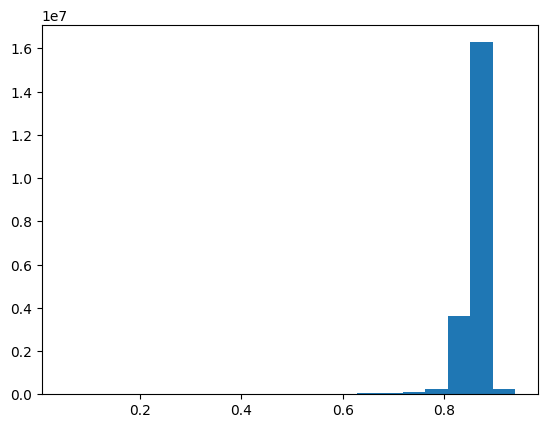

In [76]:
plt.hist(all_confs, bins = 20)

In [79]:
43 * 55

2365

In [23]:
results[0]

(array([0.9036016 , 0.90252113, 0.9021696 , ..., 0.54479027, 0.5088482 ,
        0.39782396], dtype=float32),
 array([1., 1., 1., ..., 1., 1., 1.], dtype=float32),
 array([0., 0., 0., ..., 0., 0., 0.], dtype=float32))

In [80]:
arr = np.array([e[1].sum() for e in results])
sort_idxs = np.argsort(arr)
filter_idxs = sort_idxs[1000:1100]
arr[filter_idxs]

array([2353., 2353., 2353., 2353., 2353., 2353., 2353., 2353., 2353.,
       2353., 2353., 2353., 2353., 2353., 2353., 2353., 2353., 2353.,
       2353., 2353., 2353., 2353., 2353., 2353., 2353., 2353., 2353.,
       2353., 2353., 2353., 2353., 2353., 2353., 2353., 2353., 2353.,
       2353., 2353., 2353., 2353., 2353., 2353., 2353., 2353., 2353.,
       2353., 2353., 2353., 2353., 2353., 2353., 2353., 2353., 2353.,
       2353., 2353., 2353., 2353., 2353., 2353., 2353., 2353., 2353.,
       2353., 2353., 2353., 2353., 2353., 2353., 2353., 2353., 2353.,
       2353., 2353., 2353., 2353., 2353., 2353., 2353., 2353., 2353.,
       2353., 2353., 2353., 2353., 2353., 2353., 2353., 2353., 2353.,
       2353., 2353., 2353., 2353., 2353., 2353., 2353., 2353., 2353.,
       2353.], dtype=float32)

In [81]:
2353 / 2365

0.9949260042283298

In [57]:
arr = np.array([e[2].sum() for e in results])
sort_idxs = np.argsort(arr)
filter_idxs = sort_idxs[:500]
# print(filter_idxs)
arr[filter_idxs]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [ ]:
tmp = [e for e in results if e[2].sum()]

In [ ]:
for idx in filter_idxs:
    idx = int(idx)
    sample = gt_df[idx].to_dicts()[0]
    # load image
    sample_id = sample["id"]
    type_id = sample["type_id"]
    rot_code = sample["rot_code"]
    # H is used to transform current image TO reference image
    if sample["H"] is not None:
        to_ref_H = np.array(eval(sample["H"]))
        from_ref_H = np.linalg.pinv(to_ref_H)
        # roughtly estimate the scale from current original image (000x) relative to the reference image 0001
        ori_scale_x, ori_scale_y = get_scale_xy_from_homo_mat(from_ref_H)
        # simply use single scale, avoid over-engineering
        ori_scale = (ori_scale_x * ori_scale_y) ** 0.5
    else:
        # type_id == 0001
        assert type_id == 1
        ori_scale = 1.0

    ### LOAD RGB IMAGE
    img_path = os.path.join(
        '/home/dangnh36/datasets/ecg/raw/train/', str(sample_id), f"{sample_id}-{type_id:04d}.png"
    )
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # correct the orientation
    if rot_code is not None:
        assert rot_code == int(rot_code)
        rot_code = int(rot_code)
        img = cv2.rotate(img, rot_code)

    
    viz_img_keypoints(
        img,
        grid_kpt_gt[idx][:, :2],
        [0] * len(grid_kpt_gt[idx]),
        save_path=None,
        point_size=100,
        alpha=0.9,
        show_legend=False,
        dpi=100,
    )    